<a href="https://colab.research.google.com/github/EtzionR/LM4GeoAI/blob/main/Tutorials/Tutorial_VLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial: Vision-Language Models

### created by Etzion Harari | Geo-AI Course

[**https://github.com/EtzionR/LM4GeoAI**](https://github.com/EtzionR/LM4GeoAI)

## Imports

In [1]:
from transformers import AutoProcessor, AutoModel, pipeline
from sklearn.metrics import f1_score
from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

## Define pooler output global

In [2]:
POOL = 'pooler_output'
POOL

'pooler_output'

## Define Vision-Language Model ([**CLIP**](https://arxiv.org/abs/2103.00020))

In [3]:
MODEL = "openai/clip-vit-base-patch32"
MODEL

'openai/clip-vit-base-patch32'

## Define CPU/GPU Device

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## git clone course repo for image data

In [5]:
%%bash
rm -rf NLP4GeoAI
git clone https://github.com/EtzionR/NLP4GeoAI.git

Cloning into 'NLP4GeoAI'...


## Path to Data

In [6]:
PATH = r'/content/NLP4GeoAI/Data/RSICD'
PATH

'/content/NLP4GeoAI/Data/RSICD'

## Load Images table
Based on RSICD Dataset: [RSICD](https://github.com/201528014227051/RSICD_optimal)

In [7]:
table = pd.read_csv(PATH+'/ImageTable.csv')

print(f'Number of Images: {len(table)}')

table.sample(5)

Number of Images: 200


,FileName,Label
40,Pond_1.jpg,Pond
169,Bridge_10.jpg,Bridge
13,Beach_14.jpg,Beach
86,River_7.jpg,River
142,Port_23.jpg,Port


## Display image type distribution

In [8]:
table.Label.value_counts()

,count
Label,
Beach,40
Pond,40
River,40
Port,40
Bridge,40


## Display image examples

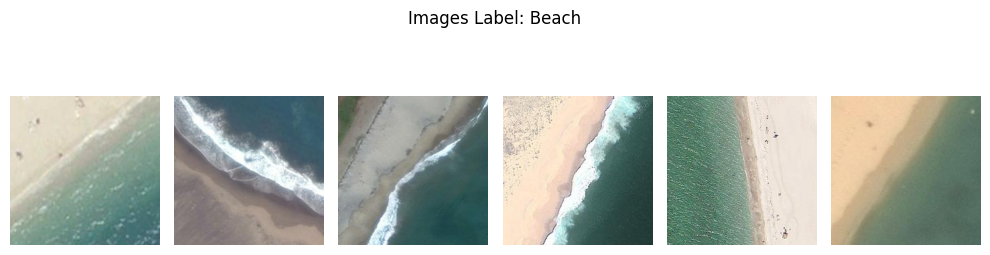

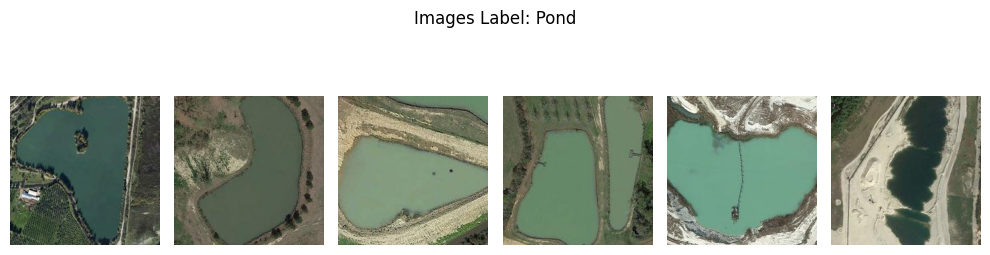

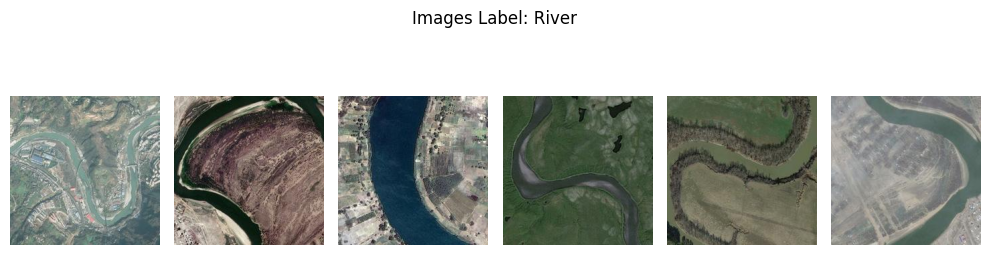

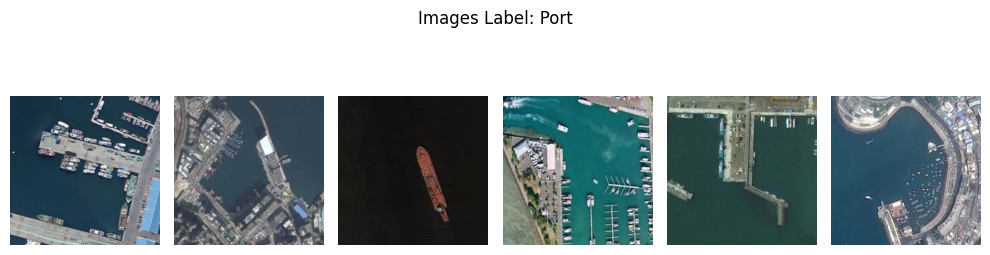

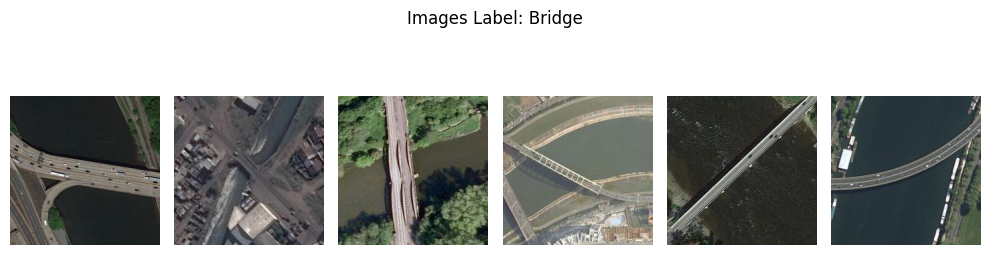

In [9]:
N = 6

for label in table.Label.unique():

    files = [*table[table.Label==label].sample(N).FileName]
    fullpaths = [PATH+'/'+file for file in files]

    images = [Image.open(path) for path in fullpaths]

    fig, axs = plt.subplots(nrows=1, ncols=N, figsize=(10,3))

    fig.suptitle(f'Images Label: {label}')
    for ax, image in zip(axs,images):
        ax.imshow(image)
        ax.axis('off')

    plt.tight_layout()

    plt.show()

## Load all Images

In [10]:
path_to_image = {filename:Image.open(PATH+'/'+filename) for filename in tqdm(table.FileName)}

print(f'\n\nNumber of images: {len(path_to_image)}')

100%|██████████| 200/200 [00:00<00:00, 8142.78it/s]



Number of images: 200


## Image example (Image index = 0)

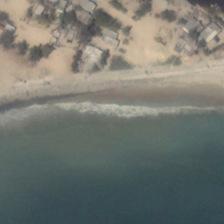

In [11]:
index = 0

path_to_image[table.FileName.iloc[index]]

## Loading CLIP model

In [12]:
model = AutoModel.from_pretrained(MODEL).to(DEVICE)
processor = AutoProcessor.from_pretrained(MODEL)

print(f'{"#"*100}\n{"\n"*5}')

model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

####################################################################################################








CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

## Get Image & Text Embeddings

In [13]:
def get_image_embedding(image):
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        image_output = model.get_image_features(**inputs)
        image_embeddings = image_output.pooler_output if hasattr(image_output, POOL) else image_output[0]
        return image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

def get_text_embedding(text):
    inputs = processor(text=text, return_tensors="pt", padding=True).to(DEVICE)

    with torch.no_grad():
        text_output = model.get_text_features(**inputs)
        text_embeddings = text_output.pooler_output if hasattr(text_output, POOL) else text_output[0]
        return text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

# Demonstartion:
# ---------------------------------------------------------------------------------------------------------

index = 0

image_embedding = get_image_embedding(path_to_image[table.FileName.iloc[index]])
text_embedding  = get_text_embedding(table.Label.iloc[index])

similarity = (image_embedding@text_embedding.T).item()

print(f'Image Embedding:\n{image_embedding[0][:3]}...\n')
print(f'Text  Embedding:\n{text_embedding[0][:3]}...\n')
print(f'Similarity for Image Index {index}: {round(similarity,3)}')

Image Embedding:
tensor([0.0136, 0.0026, 0.0155], device='cuda:0')...

Text  Embedding:
tensor([ 0.0021,  0.0123, -0.0174], device='cuda:0')...

Similarity for Image Index 0: 0.225


## Init Zero-Shot Classification object

In [14]:
zero_shot_classifier = pipeline("zero-shot-image-classification", MODEL)
zero_shot_classifier

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ZeroShotImageClassificationPipeline: {'model': 'CLIPModel', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': ('image', 'text')}

## Apply Zero-Shot Classification on single image (index = 0)

In [15]:
pd.DataFrame(zero_shot_classifier(path_to_image[table.FileName.iloc[index]],
             candidate_labels=[*table.Label.unique()])).round(3)

,score,label
0,0.962,Beach
1,0.013,Port
2,0.013,River
3,0.008,Bridge
4,0.003,Pond


## Run Zero-Shot Classification on each Image in the dataset

In [16]:
labels = [*table.Label.unique()]

predicted_labels = []
for image in tqdm(table.FileName):

    prediction = zero_shot_classifier(path_to_image[image], candidate_labels=labels)
    prediction = {dct['label']:dct['score'] for dct in prediction}

    predicted_labels.append(max(prediction, key= lambda label: prediction[label]))

table['Prediction'] = predicted_labels
table

100%|██████████| 200/200 [00:03<00:00, 50.34it/s]


,FileName,Label,Prediction
0,Beach_1.jpg,Beach,Beach
1,Beach_2.jpg,Beach,Beach
2,Beach_3.jpg,Beach,Beach
3,Beach_4.jpg,Beach,Beach
4,Beach_5.jpg,Beach,Beach
...,...,...,...
195,Bridge_36.jpg,Bridge,Bridge
196,Bridge_37.jpg,Bridge,Bridge
197,Bridge_38.jpg,Bridge,Bridge
198,Bridge_39.jpg,Bridge,Bridge


## Calculate F1 and Accuracy for the Zero-Shot task

In [17]:
ACC = (table.Label==table.Prediction).mean()
F1  = f1_score(table.Label, table.Prediction, average='macro')

print(f'Model Accuracy: {round(ACC*100,2)}%\nModel F1:       {round(ACC*100,2)}%\n')

Model Accuracy: 93.0%
Model F1:       93.0%



## display the Images with wrong prediction

In [18]:
table['ValidPrediction'] = table.Label==table.Prediction

table[table.ValidPrediction==False]

,FileName,Label,Prediction,ValidPrediction
53,Pond_14.jpg,Pond,River,False
56,Pond_17.jpg,Pond,Bridge,False
62,Pond_23.jpg,Pond,Port,False
80,River_1.jpg,River,Pond,False
82,River_3.jpg,River,Pond,False
83,River_4.jpg,River,Port,False
101,River_22.jpg,River,Pond,False
111,River_32.jpg,River,Pond,False
153,Port_34.jpg,Port,Pond,False
161,Bridge_2.jpg,Bridge,Port,False


## Display Confusion Matrix

In [19]:
labels = table.Label.unique()

confusion_matrix = {('True', label):{('Prediction', label):0 for label in labels} for label in labels}

for label, prediction in zip(table.Label, table.Prediction):
    confusion_matrix[('True', label)][('Prediction', prediction)] += 1

confusion_matrix = pd.DataFrame(confusion_matrix)
confusion_matrix

True                       
                  Beach Pond River Port Bridge
Prediction Beach     40    0     0    0      0
           Pond       0   37     4    1      0
           River      0    1    35    0      0
           Port       0    1     1   39      5
           Bridge     0    1     0    0     35

## Display the Images with wrong classification

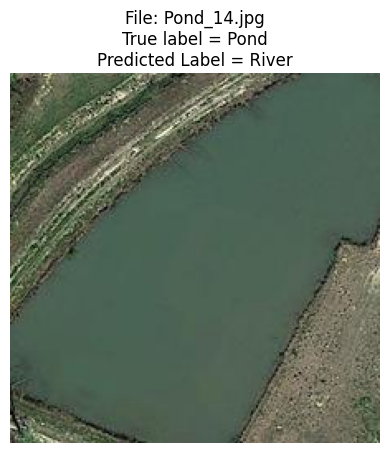

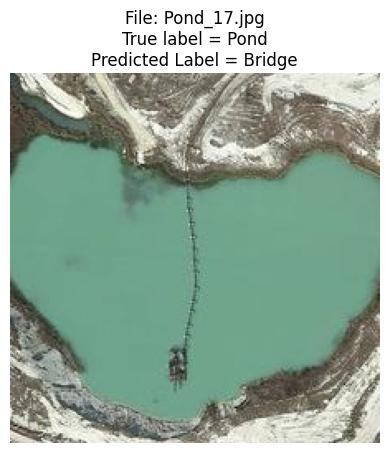

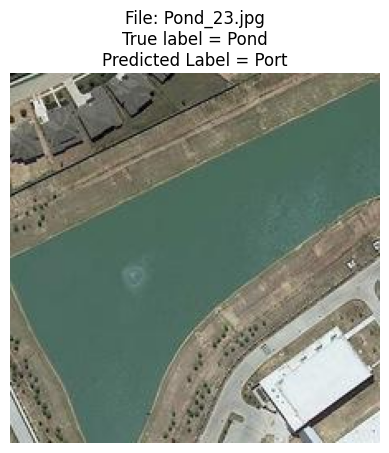

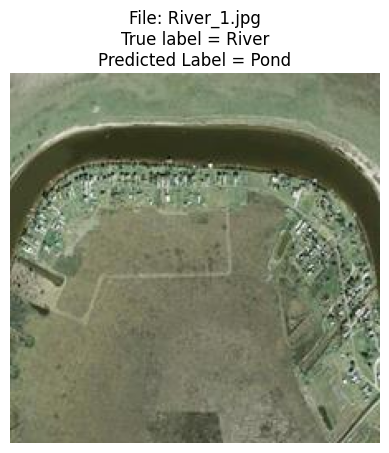

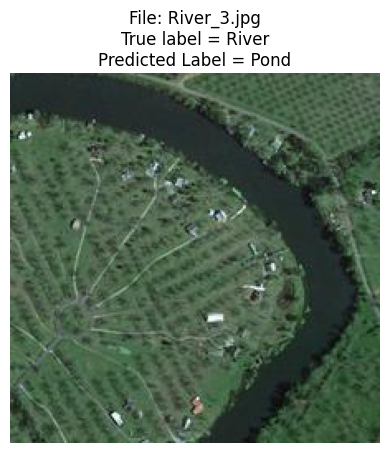

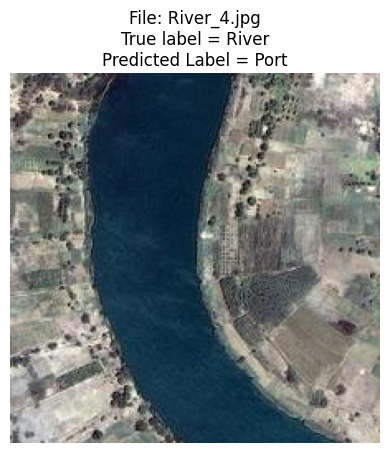

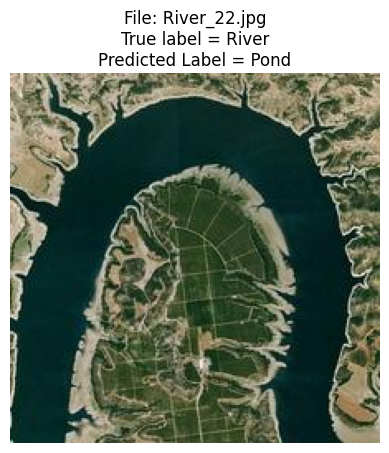

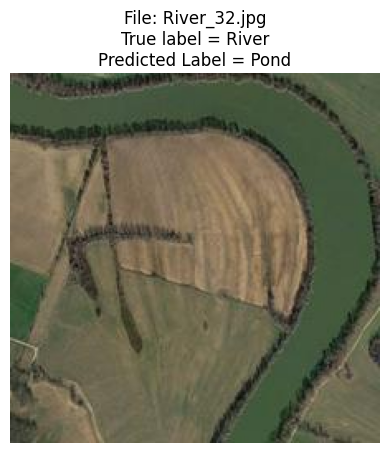

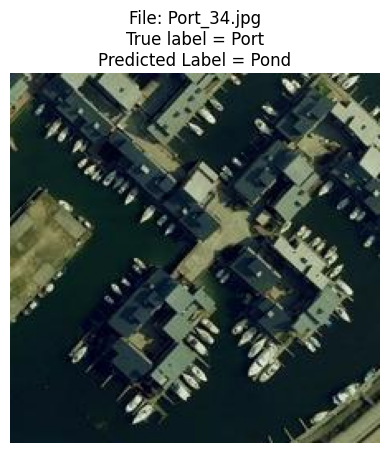

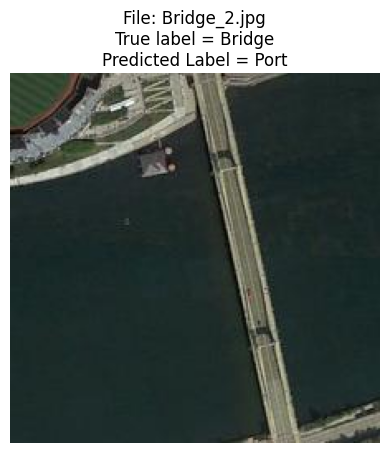

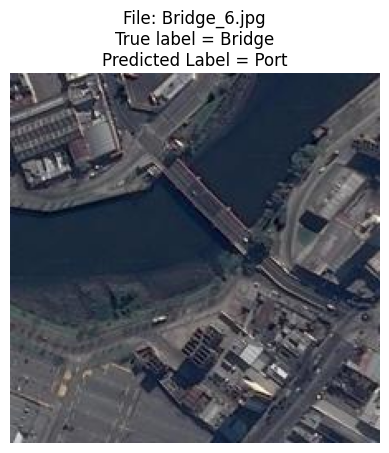

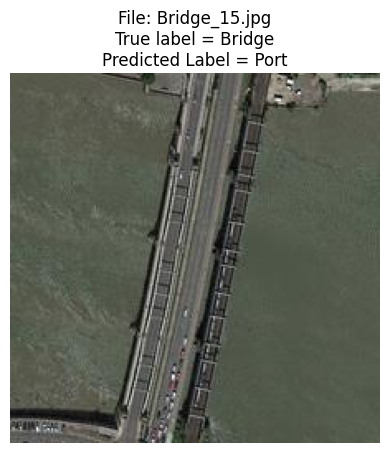

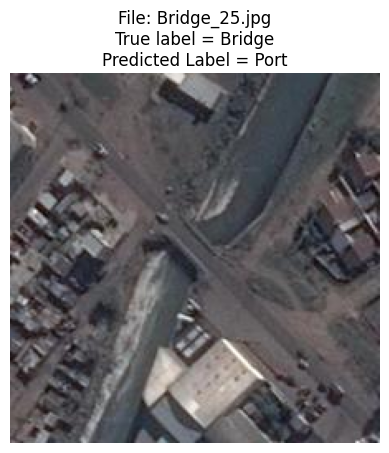

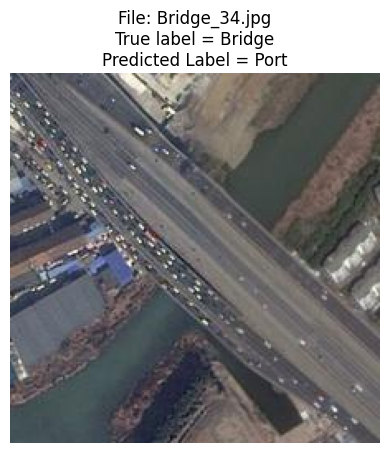

In [20]:
for file_name, label, prediction in table[table.ValidPrediction==False].iloc[:,:3].values:

    plt.title(f'File: {file_name}\nTrue label = {label}\nPredicted Label = {prediction}')
    plt.imshow(path_to_image[file_name])
    plt.axis('off')
    plt.show()

# ______________________________________________________________________________

## Image to Language Representation Learning

## Load two different images:

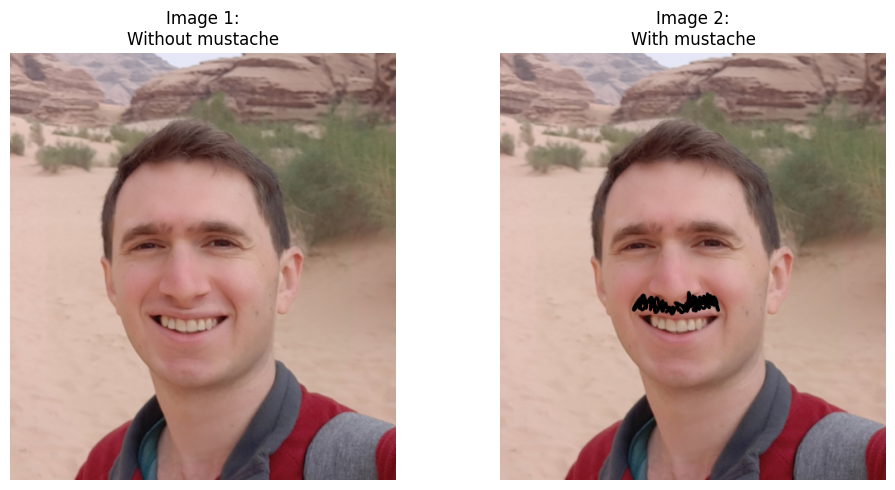

In [21]:
image_1  = Image.open(r'/content/NLP4GeoAI/Data/ImageLangRepr/without.png')
image_2  = Image.open(r'/content/NLP4GeoAI/Data/ImageLangRepr/with.png')
mustache = 'mustache'

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2, figsize=(10,5))

ax1.set_title(f'Image 1:\nWithout {mustache}')
ax2.set_title(f'Image 2:\nWith {mustache}')

ax1.imshow(image_1)
ax2.imshow(image_2)

ax1.axis('off')
ax2.axis('off')

plt.tight_layout()
plt.show()

## Calculate Gap in image embedding

In [22]:
image_1_embedding = get_image_embedding(image_1)
image_2_embedding = get_image_embedding(image_2)

delta = image_2_embedding-image_1_embedding

delta.shape

torch.Size([1, 512])

## Loading words list

In [23]:
words_path = r'/content/NLP4GeoAI/Data/ImageLangRepr/WORDS.txt'

with open(words_path, 'r') as f:
    words = f.read().split('\n')

print(f'{len(words)} Words in english loaded')

55164 Words in english loaded


## Search for matching word for the delta vector

In [24]:
N = 250

words_sample = list(np.random.choice(words, N-1))+[mustache]

similarity_table = []

for word in tqdm(words_sample):

    word_embedding = get_text_embedding(word)

    similarity_table.append({'Word':word, 'Score':(word_embedding@delta.T).item()})

similarity_table = pd.DataFrame(similarity_table).sort_values('Score', ascending=False).reset_index(drop=True).round(2)

print(f'\n\nThe word with the highest similarity:\n"{similarity_table.Word.iloc[0]}"\n')

similarity_table

100%|██████████| 250/250 [00:02<00:00, 108.91it/s]



The word with the highest similarity:
"mustache"



,Word,Score
0,mustache,0.10
1,commissioner,0.04
2,mu,0.04
3,spoofs,0.04
4,flax,0.04
...,...,...
245,tapestries,-0.01
246,downpour,-0.01
247,helplessness,-0.01
248,dislodging,-0.01


Create by Etzion Harari | Geo-AI Course | [https://github.com/EtzionR/LM4GeoAI](https://github.com/EtzionR/LM4GeoAI)